In [92]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
# import torch.nn.functional as F
# from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset
!pip install torchsummary
from torchsummary import summary
from random import shuffle, seed
from PIL import Image
from torch import optim
from glob import glob
import cv2

In [93]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [94]:
train_data_dir = '/kaggle/input/cat-and-dog/training_set/training_set'
test_data_dir = '/kaggle/input/cat-and-dog/test_set/test_set'

In [95]:
cat = glob(train_data_dir+'/cats/*.jpg')
dog = glob(train_data_dir+'/dogs/*.jpg')
folder_paths = cat + dog
display('cat samples: ', list(folder_paths)[:3])
display('dog samples: ', list(folder_paths)[-3:])

'cat samples: '

['/kaggle/input/cat-and-dog/training_set/training_set/cats/cat.3498.jpg',
 '/kaggle/input/cat-and-dog/training_set/training_set/cats/cat.891.jpg',
 '/kaggle/input/cat-and-dog/training_set/training_set/cats/cat.2842.jpg']

'dog samples: '

['/kaggle/input/cat-and-dog/training_set/training_set/dogs/dog.3865.jpg',
 '/kaggle/input/cat-and-dog/training_set/training_set/dogs/dog.1783.jpg',
 '/kaggle/input/cat-and-dog/training_set/training_set/dogs/dog.1631.jpg']

In [96]:
cat = glob(test_data_dir+'/cats/*.jpg')
dog = glob(test_data_dir+'/dogs/*.jpg')
folder_paths = cat + dog
display('cat samples: ', list(folder_paths)[:3])
display('dog samples: ', list(folder_paths)[-3:])

'cat samples: '

['/kaggle/input/cat-and-dog/test_set/test_set/cats/cat.4414.jpg',
 '/kaggle/input/cat-and-dog/test_set/test_set/cats/cat.4420.jpg',
 '/kaggle/input/cat-and-dog/test_set/test_set/cats/cat.4880.jpg']

'dog samples: '

['/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4436.jpg',
 '/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4874.jpg',
 '/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4799.jpg']

In [165]:
class TrainData(Dataset):
    def __init__(self, folder):
        # train data paths
        cat = glob(train_data_dir+'/cats/*.jpg')
        dog = glob(train_data_dir+'/dogs/*.jpg')
        # a tiny part of data
        cat = cat[:1500]
        dog = dog[:1500]
        self.folder_paths = cat + dog
        # print(self.folder_paths)
        # shuffle data
        seed(10)
        shuffle(self.folder_paths)
        # data labels
        self.targets = [1 if path.split('/')[-1].startswith('cat') else 0 for path in self.folder_paths] # 1 for cat, 0 for dog
        
    def __len__(self): 
        return len(self.folder_paths)
        
    def __getitem__(self, ix):
        file = self.folder_paths[ix]
        target = self.targets[ix]
        target = torch.tensor(target)
        image = cv2.imread(file)[:, :, ::-1] # all rows and cols, reverse the channels bgr -> rgb
        image = cv2.resize(image, (224, 224)) # resizing image
        image = image / 255 # scaling
        image = torch.tensor(image).permute(2, 0, 1) # [224, 224, 3] -> [3, 224, 224]
        return image.float().to(device), target.float().to(device)

train_data = TrainData(train_data_dir)
print(len(train_data))

3000


Text(0.5, 1.0, "tensor(0., device='cuda:0')")

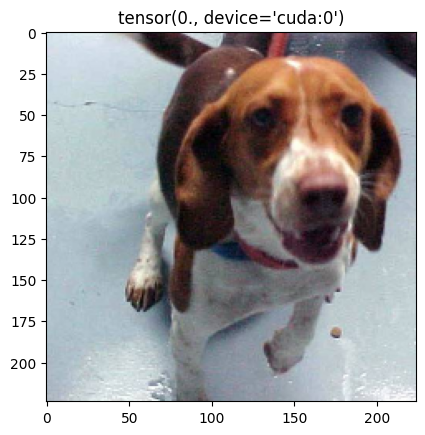

In [166]:
image , label = train_data[300]
plt.imshow(image.permute(1, 2, 0).cpu())
plt.title(label)

In [167]:
class TestData(Dataset):
    def __init__(self, folder):
        # train data paths
        cat = glob(test_data_dir+'/cats/*.jpg')
        dog = glob(test_data_dir+'/dogs/*.jpg')
        # a tiny part of data
        cat = cat[:200]
        dog = dog[:200]
        self.folder_paths = cat + dog
        # print(self.folder_paths)
        # shuffle data
        seed(10)
        shuffle(self.folder_paths)
        # data labels
        self.targets = [1 if path.split('/')[-1].startswith('cat') else 0 for path in self.folder_paths] # 1 for cat, 0 for dog
        
    def __len__(self): 
        return len(self.folder_paths)
        
    def __getitem__(self, ix):
        file = self.folder_paths[ix]
        target = self.targets[ix]
        target = torch.tensor(target)
        image = cv2.imread(file)[:, :, ::-1] # all rows and cols, reverse the channels bgr -> rgb
        image = cv2.resize(image, (224, 224)) # resizing image
        image = image / 255 # scaling
        image = torch.tensor(image).permute(2, 0, 1) # [224, 224, 3] -> [3, 224, 224]
        return image.float().to(device), target.float().to(device)

test_data = TestData(train_data_dir)
print(len(test_data))

400


Text(0.5, 1.0, "tensor(1., device='cuda:0')")

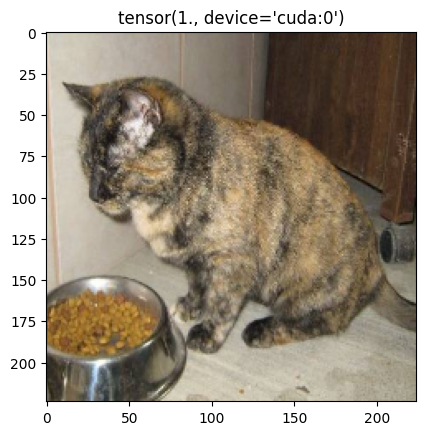

In [168]:
image , label = test_data[25]
plt.imshow(image.permute(1, 2, 0).cpu())
plt.title(label)

In [169]:
def conv_layer(inputs, outputs, kernel_size, stride=1):
    return nn.Sequential(
        nn.Conv2d(inputs, outputs, kernel_size, stride),
        nn.ReLU(),
        nn.BatchNorm2d(outputs),
        nn.MaxPool2d(2)
    )

In [171]:
def get_model():
    model = nn.Sequential(
        conv_layer(3, 64, 3),
        conv_layer(64, 512, 3),
        conv_layer(512, 512, 3),
        conv_layer(512, 512, 3),
        conv_layer(512, 512, 3),
        conv_layer(512, 512, 3),
        nn.Flatten(),
        nn.Linear(512, 1),
        nn.Sigmoid()
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(),lr=0.001)
    loss_func = nn.BCELoss()
    return model, optimizer, loss_func
model, optimizer, loss_func = get_model()
summary(model, (3, 244, 244))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 242, 242]           1,792
              ReLU-2         [-1, 64, 242, 242]               0
       BatchNorm2d-3         [-1, 64, 242, 242]             128
         MaxPool2d-4         [-1, 64, 121, 121]               0
            Conv2d-5        [-1, 512, 119, 119]         295,424
              ReLU-6        [-1, 512, 119, 119]               0
       BatchNorm2d-7        [-1, 512, 119, 119]           1,024
         MaxPool2d-8          [-1, 512, 59, 59]               0
            Conv2d-9          [-1, 512, 57, 57]       2,359,808
             ReLU-10          [-1, 512, 57, 57]               0
      BatchNorm2d-11          [-1, 512, 57, 57]           1,024
        MaxPool2d-12          [-1, 512, 28, 28]               0
           Conv2d-13          [-1, 512, 26, 26]       2,359,808
             ReLU-14          [-1, 512,

In [172]:
def get_data():
    train = TrainData(train_data_dir)
    train_dl = DataLoader(train, batch_size=30, shuffle=True)
    val = TestData(test_data_dir)
    val_dl = DataLoader(val, batch_size=30, shuffle=True, drop_last=True)
    return train_dl, val_dl
train_dl , val_dl = get_data()
print('train batches: ', len(train_dl))
print('test batches: ', len(val_dl))

train batches:  100
test batches:  13


In [173]:
def train_batch(x, y, model, optimizer, loss_func):
    model.train()
    prediction = model(x) # shape[30, 1]
    batch_loss = loss_func(prediction, y.view(-1, 1)) # prediction and y should have same shape
    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    return batch_loss.item()

In [174]:
@torch.no_grad()
def accuracy(x, y, model):
    model.eval()
    with torch.no_grad():
        y_pred = model(x)
        preds = (y_pred > 0.5).float()
        correct = (preds == y.view(-1, 1)).float().mean().item() # prediction and y should have same shape
    return correct

In [175]:
@torch.no_grad()
def validation_loss(x, y, model):
    model.eval()
    prediction = model(x)
    val_loss = loss_func(prediction, y.view(-1, 1))
    return val_loss.item()

In [176]:
# model training
train_losses , train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(5):
    print('epoch: ', epoch+1)
    train_epoch_losses, train_epoch_accuracies = [], []
    val_epoch_accuracies = []
    # train
    for ix, batch in enumerate(iter(train_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_func)
        train_epoch_losses.append(batch_loss)
    train_epoch_loss = np.array(train_epoch_losses).mean()
    # accuracy
    for ix, batch in enumerate(iter(train_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.append(is_correct)
    train_epoch_accuracy = np.mean(train_epoch_accuracies)
    
    # Validation loop
    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        val_epoch_accuracies.append(val_is_correct)
    val_epoch_accuracy = np.mean(val_epoch_accuracies)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_accuracies.append(val_epoch_accuracy)

epoch:  1
epoch:  2
epoch:  3
epoch:  4
epoch:  5


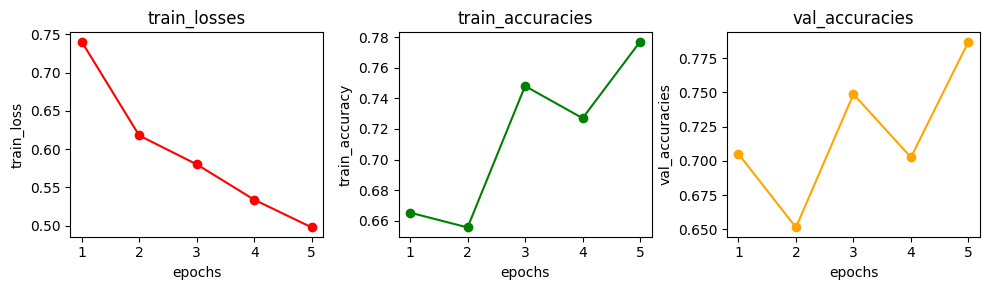

In [201]:
epochs = np.arange(5)+1
fig, axes = plt.subplots(1,3, figsize=(10, 3))
axes[0].plot(epochs, train_losses, marker='o', color='red')
axes[0].set_title('train_losses')
axes[0].set_xlabel('epochs')
axes[0].set_ylabel('train_loss')

axes[1].plot(epochs, train_accuracies, marker='o', color='green')
axes[1].set_title('train_accuracies')
axes[1].set_xlabel('epochs')
axes[1].set_ylabel('train_accuracy')

axes[2].plot(epochs, val_accuracies, marker='o', color='orange')
axes[2].set_title('val_accuracies')
axes[2].set_xlabel('epochs')
axes[2].set_ylabel('val_accuracies')
# manage spaces
plt.tight_layout()
plt.show()